DT range: -999.0 89.620895


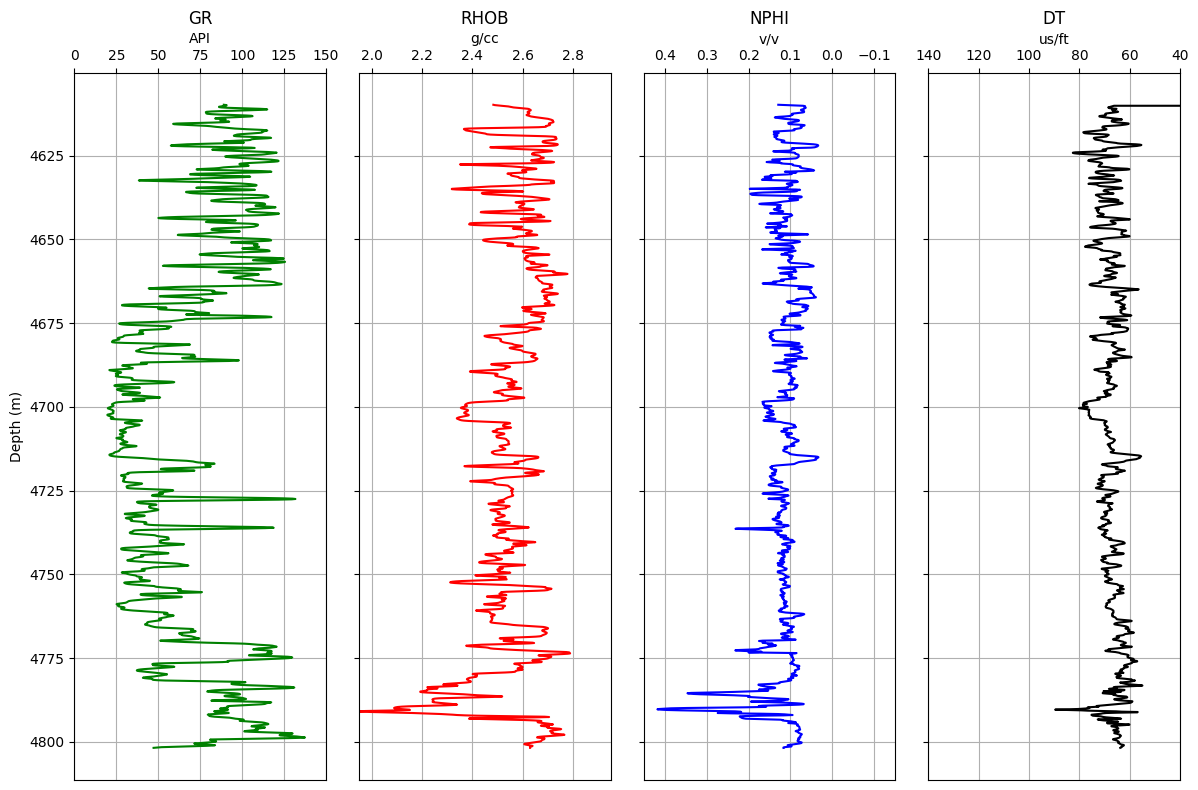

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------- LOAD DATA --------------------
df = pd.read_csv('WellData (1).csv')

# Clean column names
df.columns = df.columns.str.strip()

# Required columns
cols = ['DEPTH', 'GR', 'RHOB', 'NPHI', 'DT']

# Convert to numeric
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop missing values
df = df.dropna(subset=cols)

# Sort by depth
df = df.sort_values(by='DEPTH')

# -------------------- CHECK DT UNIT --------------------
print("DT range:", df['DT'].min(), df['DT'].max())

# If DT looks too large → convert (µs/m → µs/ft)
if df['DT'].max() > 200:
    df['DT'] = df['DT'] / 3.281
    print("Converted DT from us/m to us/ft")

# -------------------- PLOT --------------------
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12,8), sharey=True)

# ---- GR ----
axes[0].plot(df['GR'], df['DEPTH'], color='green')
axes[0].set_xlim(0, 150)
axes[0].set_title("GR")
axes[0].set_xlabel("API")
axes[0].invert_yaxis()
axes[0].xaxis.tick_top()
axes[0].xaxis.set_label_position('top')
axes[0].grid()

# ---- RHOB ----
axes[1].plot(df['RHOB'], df['DEPTH'], color='red')
axes[1].set_xlim(1.95, 2.95)
axes[1].set_title("RHOB")
axes[1].set_xlabel("g/cc")
axes[1].xaxis.tick_top()
axes[1].xaxis.set_label_position('top')
axes[1].grid()

# ---- NPHI ----
axes[2].plot(df['NPHI'], df['DEPTH'], color='blue')
axes[2].set_xlim(0.45, -0.15)   # reversed scale (industry style)
axes[2].set_title("NPHI")
axes[2].set_xlabel("v/v")
axes[2].xaxis.tick_top()
axes[2].xaxis.set_label_position('top')
axes[2].grid()

# ---- DT (Sonic) ----
axes[3].plot(df['DT'], df['DEPTH'], color='black')
axes[3].set_xlim(140, 40)   # reversed axis (IMPORTANT 🔥)
axes[3].set_title("DT")
axes[3].set_xlabel("us/ft")
axes[3].xaxis.tick_top()
axes[3].xaxis.set_label_position('top')
axes[3].grid()

# Common Y-axis
axes[0].set_ylabel("Depth (m)")

# Layout
plt.tight_layout()
plt.show()

 Interpretation of GR vs Depth Log

The GR log shows clear variation with depth, indicating interbedded lithologies. High GR intervals correspond to shale-rich zones, while low GR intervals represent cleaner sandstone units.

Multiple alternating high and low GR patterns suggest repeated deposition of shale and sand layers, indicating cyclic sedimentation. The log shows distinct low GR intervals at certain depth ranges, which can be interpreted as potential reservoir zones, separated by high GR shale intervals acting as barriers or seal rocks.

The nature of GR variation does not remain uniform with depth, indicating changes in depositional conditions over time. Overall, the well log reflects a heterogeneous subsurface sequence with interbedded reservoir and non-reservoir units.

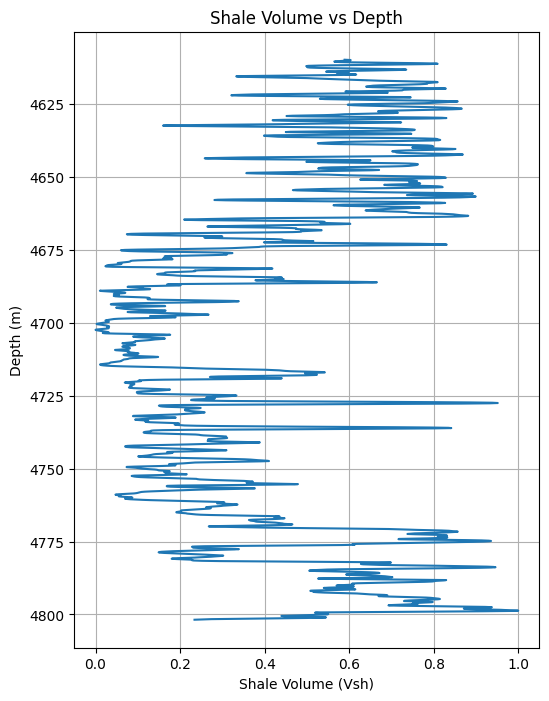

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("WellData.csv")

# GR values
GR = df["GR"]

# Define GR min and max (you can also take percentile-based values for better accuracy)
GR_min = GR.min()
GR_max = GR.max()

# Shale Volume calculation
df["Vsh"] = (GR - GR_min) / (GR_max - GR_min)

# Clip values between 0 and 1
df["Vsh"] = np.clip(df["Vsh"], 0, 1)

# Plot Vsh vs Depth
plt.figure(figsize=(6,8))
plt.plot(df["Vsh"], df["DEPTH"])
plt.gca().invert_yaxis()

plt.xlabel("Shale Volume (Vsh)")
plt.ylabel("Depth (m)")
plt.title("Shale Volume vs Depth")

plt.grid()
plt.show()

Interpretation of Shale Volume (Vsh)

The shale volume (Vsh) log shows vertical variation in clay content with depth, derived from Gamma Ray values. The log indicates alternating intervals of low and high shale content, reflecting heterogeneity in the subsurface formation.

Low Vsh intervals (< 0.3) correspond to clean sandstone units, which are likely high-quality reservoir zones due to better porosity and permeability. Moderate Vsh values (0.3–0.5) indicate shaly sand zones, which may act as poor to moderate reservoirs depending on clay content. High Vsh intervals (> 0.5) represent shale-dominated zones, which generally act as sealing units with low permeability.

Overall, the Vsh log confirms the presence of interbedded reservoir (sand) and non-reservoir (shale) layers, supporting a heterogeneous depositional system and potential reservoir–seal architecture suitable for hydrocarbon trapping.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("WellData.csv")

# remove missing basic data
df = df.dropna(subset=["GR", "DEPTH"])

# GR min-max method
GR_min = df["GR"].min()
GR_max = df["GR"].max()

df["Vsh"] = (df["GR"] - GR_min) / (GR_max - GR_min)
df["Vsh"] = np.clip(df["Vsh"], 0, 1)

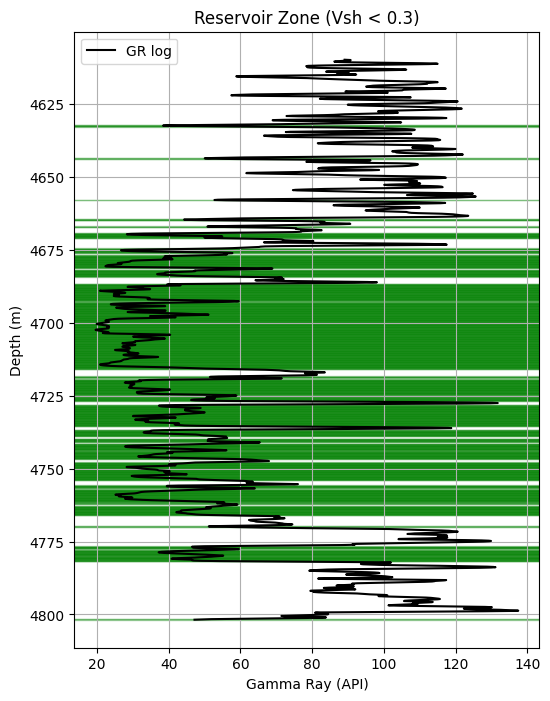

In [21]:
cutoff = 0.3

df["is_reservoir"] = df["Vsh"] < cutoff

df = df.sort_values("DEPTH")

plt.figure(figsize=(6,8))

plt.plot(df["GR"], df["DEPTH"], color="black", label="GR log")

for i in range(len(df)-1):
    if df["is_reservoir"].iloc[i]:
        plt.axhspan(df["DEPTH"].iloc[i],
                    df["DEPTH"].iloc[i+1],
                    color="green",
                    alpha=0.3)

plt.gca().invert_yaxis()

plt.xlabel("Gamma Ray (API)")
plt.ylabel("Depth (m)")
plt.title("Reservoir Zone (Vsh < 0.3)")
plt.legend()
plt.grid()

plt.show()

 Interpretation of Reservoir Zone (Vsh-based Analysis)

The Vsh-derived reservoir analysis shows a clear vertical distribution of reservoir and non-reservoir intervals within the well section. Zones with low Vsh (< 0.3) correspond to clean sandstone units, which are interpreted as potential reservoir intervals due to their higher effective porosity and permeability. These zones appear as discrete intervals separated by shale-rich sections.

Intervals with high Vsh (> 0.5) represent shale-dominated lithologies, which act as impermeable barriers and likely serve as seal rocks. The alternating pattern of reservoir and shale zones indicates a heterogeneous stratigraphic sequence.

The overall distribution suggests a compartmentalized reservoir system, where sandstone bodies are vertically isolated by shale layers. Such architecture is favorable for hydrocarbon entrapment, provided sufficient charge and structural closure are present.

1.  Conclusion


“The well log analysis using Gamma Ray and derived shale volume indicates a heterogeneous subsurface sequence composed of interbedded sandstone and shale. Low Vsh intervals represent potential reservoir zones, while high Vsh intervals act as sealing units. The presence of multiple reservoir–seal alternations suggests a favorable stratigraphic setup for hydrocarbon accumulation.”

2.  Limitations

“The interpretation is based only on Gamma Ray-derived shale volume and does not incorporate porosity, resistivity, or fluid saturation data, which are essential for full reservoir characterization.”